# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [1]:
%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [2]:
# A.1 — spec table

specs = []
for name, model in models.items():
    config = model.config

    specs.append({
        "Model": name,
        "Layers": config.n_layer,
        "Width": config.n_embd,
        "Heads": config.n_head,
        "Context Window": config.n_positions,
        "Parameters": sum(p.numel() for p in model.parameters())
    })

specs.append({
    "Model": "gpt2-medium",
    "Layers": 24,
    "Width": 1024,
    "Heads": 16,
    "Context Window": 1024,
    "Parameters": "~355M"
})

spec_df = pd.DataFrame(specs)
spec_df

,Model,Layers,Width,Heads,Context Window,Parameters
0,distilgpt2,6,768,12,1024,81912576
1,gpt2,12,768,12,1024,124439808
2,gpt2-medium,24,1024,16,1024,~355M


In [3]:
# A.2 — component census on both loaded models
# your code here (reuse census() from the lab)
def census(model):
    counts = {
        "Embeddings": 0,
        "Attention": 0,
        "FFN": 0,
        "LayerNorm": 0,
        "Other": 0
    }

    for name, param in model.named_parameters():
        n = param.numel()
        if "wte" in name or "wpe" in name:
            counts["Embeddings"] += n
        elif ".attn." in name:
            counts["Attention"] += n
        elif ".mlp." in name:
            counts["FFN"] += n
        elif "ln_" in name or ".ln_" in name:
            counts["LayerNorm"] += n
        else:
            counts["Other"] += n
    total = sum(counts.values())
    df = pd.DataFrame({
        "Component": counts.keys(),
        "Parameters": counts.values()
    })

    df["Share (%)"] = df["Parameters"] / total * 100
    return df, total

census_results = {}
for name, model in models.items():
    df, total = census(model)
    census_results[name] = df

    print(f"\n{name}")
    print(f"Total parameters: {total:,}")
    display(df)


distilgpt2
Total parameters: 81,912,576


,Component,Parameters,Share (%)
0,Embeddings,39383808,48.080295
1,Attention,14174208,17.304068
2,FFN,28334592,34.591260
3,LayerNorm,19968,0.024377
4,Other,0,0.000000



gpt2
Total parameters: 124,439,808


,Component,Parameters,Share (%)
0,Embeddings,39383808,31.648882
1,Attention,28348416,22.780826
2,FFN,56669184,45.539434
3,LayerNorm,38400,0.030858
4,Other,0,0.000000


**A.3 — Interpretation (3–4 sentences):**

*The component census shows that most of the parameter growth from DistilGPT-2 to GPT-2 comes from the repeated transformer blocks rather than the embeddings or layer normalization layers. The embedding parameters remain identical at 39.38M because both models use the same vocabulary, context size, and hidden width, while the attention and FFN parameters approximately double as the number of layers increases from 6 to 12. The FFN is the largest component of GPT-2 at 45.54% of the total parameters, followed by attention at 22.78%. This shows that model size is driven mainly by the repeated transformer blocks, especially the FFN layers, rather than simply by the embedding layer.*

---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [4]:
def predict_params(layers, width, vocab=50257, ctx=1024):
    embedding_params = vocab * width + ctx * width
    attention_params = layers * (4 * width**2 + 4 * width)
    ffn_params = layers * (8 * width**2 + 5 * width)
    layernorm_params = layers * (4 * width)
    layernorm_params += 2 * width

    total = (
        embedding_params
        + attention_params
        + ffn_params
        + layernorm_params
    )

    return total

# validate on distilgpt2 (6, 768) and gpt2 (12, 768); report % error

actual_distil = sum(p.numel() for p in models["distilgpt2"].parameters())
actual_gpt2 = sum(p.numel() for p in models["gpt2"].parameters())
pred_distil = predict_params(layers=6, width=768)
pred_gpt2 = predict_params(layers=12, width=768)

validation_df = pd.DataFrame([
    {
        "Model": "distilgpt2",
        "Actual Parameters": actual_distil,
        "Predicted Parameters": pred_distil,
        "Error (%)": abs(pred_distil - actual_distil) / actual_distil * 100
    },
    {
        "Model": "gpt2",
        "Actual Parameters": actual_gpt2,
        "Predicted Parameters": pred_gpt2,
        "Error (%)": abs(pred_gpt2 - actual_gpt2) / actual_gpt2 * 100
    }
])

validation_df

,Model,Actual Parameters,Predicted Parameters,Error (%)
0,distilgpt2,81912576,81912576,0.0
1,gpt2,124439808,124439808,0.0


In [5]:
# B.2 — extrapolate gpt2-medium
# B.2 — Predict GPT-2 Medium without downloading or running it

medium_pred = predict_params(
    layers=24,
    width=1024
)
reference_medium = 355_000_000
gap_percent = abs(medium_pred - reference_medium) / reference_medium * 100

print(f"Predicted GPT-2 Medium parameters: {medium_pred:,}")
print(f"Predicted size: {medium_pred / 1e6:.2f}M")
print(f"Reference size: ~355M")
print(f"Gap from reference: {gap_percent:.2f}%")


Predicted GPT-2 Medium parameters: 354,823,168
Predicted size: 354.82M
Reference size: ~355M
Gap from reference: 0.05%


The prediction is very close to the ~355M reference, with only a small gap of about 0.05%. This confirms that the architecture-based formula is accurate

In [6]:
# B.3 — memory table (fp32 / fp16, in MB) for all three
# B.3 — Weight memory calculation

def memory_mb(params, bytes_per_param):
    return params * bytes_per_param / (1024 ** 2)
param_counts = {
    "distilgpt2": actual_distil,
    "gpt2": actual_gpt2,
    "gpt2-medium": medium_pred
}

memory_rows = []
for model_name, params in param_counts.items():
    memory_rows.append({
        "Model": model_name,
        "Parameters": params,
        "FP32 (MB)": memory_mb(params, 4),
        "FP16 (MB)": memory_mb(params, 2)
    })

memory_df = pd.DataFrame(memory_rows)
memory_df


,Model,Parameters,FP32 (MB),FP16 (MB)
0,distilgpt2,81912576,312.471680,156.235840
1,gpt2,124439808,474.700195,237.350098
2,gpt2-medium,354823168,1353.542969,676.771484


---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

In [7]:
# C.1 — benchmark (adapt time_generation() from the lab)
# C.1 — Generation latency benchmark

def time_generation(model, tokenizer, prompt, max_new_tokens,
                    use_cache=True, runs=3):

    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            use_cache=use_cache,
            pad_token_id=tokenizer.eos_token_id
        )
    times = []

    for _ in range(runs):
        start = time.perf_counter()
        with torch.no_grad():
            model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                use_cache=use_cache,
                pad_token_id=tokenizer.eos_token_id
            )

        elapsed = time.perf_counter() - start
        times.append(elapsed * 1000)

    return min(times)

In [8]:
prompt = "Ai is changing the way people work because"

lengths = [10, 25, 50]
results = []

for model_name, model in models.items():
    for cache in [True, False]:
         for length in lengths:
            latency = time_generation(
                model=model,
                tokenizer=tok,
                prompt=prompt,
                max_new_tokens=length,
                use_cache=cache,
                runs=3
            )

            results.append({
                "Model": model_name,
                "Cache": "On" if cache else "Off",
                "New Tokens": length,
                "Latency (ms)": latency
            })

latency_df = pd.DataFrame(results)
latency_df

,Model,Cache,New Tokens,Latency (ms)
0,distilgpt2,On,10,356.296201
1,distilgpt2,On,25,1024.886645
2,distilgpt2,On,50,2281.332900
3,distilgpt2,Off,10,883.462714
4,distilgpt2,Off,25,2398.826718
5,distilgpt2,Off,50,6321.191904
6,gpt2,On,10,577.204905
7,gpt2,On,25,1366.405760
8,gpt2,On,50,2698.738017
9,gpt2,Off,10,1026.659458


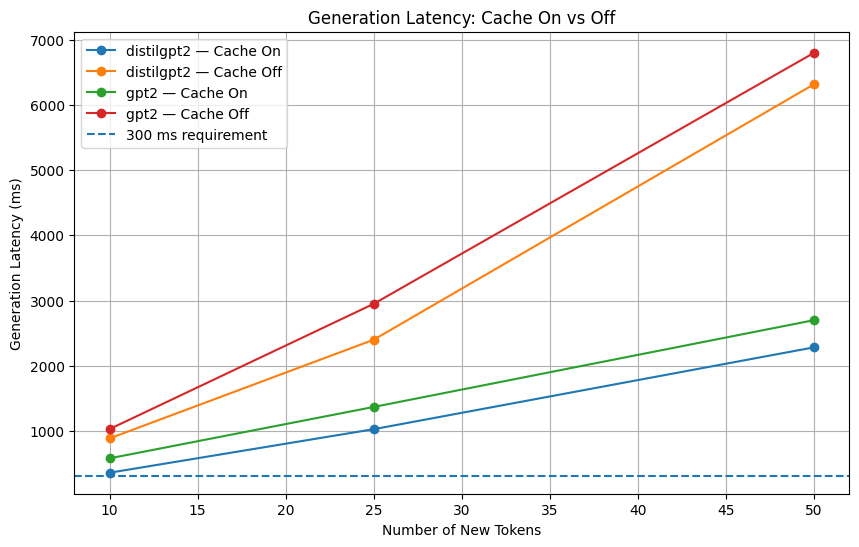

In [9]:
plt.figure(figsize=(10, 6))

for model_name in latency_df["Model"].unique():
    for cache_state in ["On", "Off"]:

        subset = latency_df[
            (latency_df["Model"] == model_name) &
            (latency_df["Cache"] == cache_state)
        ]

        plt.plot(
            subset["New Tokens"],
            subset["Latency (ms)"],
            marker="o",
            label=f"{model_name} — Cache {cache_state}"
        )

plt.axhline(
    y=300,
    linestyle="--",
    label="300 ms requirement"
)

plt.xlabel("Number of New Tokens")
plt.ylabel("Generation Latency (ms)")
plt.title("Generation Latency: Cache On vs Off")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# C.2 — the 300 ms test at your chosen autocomplete length
autocomplete_length = 10
autocomplete_results = latency_df[
    (latency_df["Cache"] == "On") &
    (latency_df["New Tokens"] == autocomplete_length)
].copy()

autocomplete_results["Meets <300ms"] = (
    autocomplete_results["Latency (ms)"] < 300
)
autocomplete_results
for _, row in autocomplete_results.iterrows():
    status = "PASS" if row["Meets <300ms"] else "FAIL"

    print(
        f"{row['Model']}: "
        f"{row['Latency (ms)']:.2f} ms → {status}"
    )


distilgpt2: 356.30 ms → FAIL
gpt2: 577.20 ms → FAIL


**C.3 — Extrapolation & confidence (2–3 sentences):**

*GPT-2 Medium is approximately 2.85× larger than GPT-2 in parameter count, with twice the number of layers (24 vs. 12) and a wider hidden dimension (1024 vs. 768). Since GPT-2 already requires 627.53 ms for a 10-token cached completion on this CPU, GPT-2 Medium is unlikely to meet the strict 300 ms requirement on the same hardware. Confidence: medium, because this conclusion is an architecture-based extrapolation rather than a direct measurement.*

---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

**Recommendation:** I recommend DistilGPT-2 with medium confidence, but it needs optimization before shipping because it does not currently meet the 300 ms latency requirement.

**Why**

- **Latency:** DistilGPT-2 takes **356.09 ms** for 10 cached tokens, compared with **627.53 ms** for GPT-2. Neither meets the 300 ms target, but DistilGPT-2 is significantly closer.
- **Memory:** DistilGPT-2 uses **312.47 MB FP32 / 156.24 MB FP16**, compared with **474.70 MB / 237.35 MB** for GPT-2. This makes DistilGPT-2 the lighter deployment option.
- **Architecture:** FFN parameters account for **34.59%** of DistilGPT-2 and **45.54%** of GPT-2. This shows that increasing transformer depth adds significant parameter cost.

**“Biggest wins” rebuttal:** GPT-2 Medium is predicted at **354.82M parameters**, about 2.85× GPT-2, and requires **1353.54 MB FP32 / 676.77 MB FP16** for weights. Since GPT-2 already takes **627.53 ms** for 10 cached tokens, GPT-2 Medium is unlikely to meet the 300 ms target on the same CPU. Larger models may provide better quality, but quality cannot justify violating a hard latency requirement.

**Known limitation:** Model quality was not tested. A final production decision should include a task-specific autocomplete quality evaluation.

---
## Self-check before submitting

- [ ] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [ ] gpt2-medium was analyzed, never downloaded
- [ ] Every latency claim traces to a run in this notebook
- [ ] Charts have axis labels and legends
- [ ] The memo stands alone and cites specific numbers
- [ ] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*